In [ ]:
import sys
import os

# Get the path of the current file or notebook
current_path = os.path.abspath(
    __file__ if "__file__" in locals() else os.getcwd()
)

# Get the parent directory
parent_dir = os.path.dirname(current_path)
print(f"Parent directory: {parent_dir}")
# Add the parent directory to sys.path if it's not already there
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

Parent directory: /home/fanghan/Work/spebt/packages/pymatcal


In [ ]:
import time

from torch import Tensor, cat, device
from torch import empty as empty_tensor
from torch import float32 as torch_float32
from torch import float64 as torch_float64
from torch import get_num_threads, pi, tensor
from torch import zeros as zeros_tensor

from scanner_modeling._convex_hull._convex_hull_functions import (
    convex_hull_2d,
    sort_points_for_hull_2d,
)
from scanner_modeling._raytracer_2d._local_functions import (
    line_segments_t,
    rays_2d_batch,
    rays_edges_t_subdivisions,
    rays_intersection_lengths,
    sfov_properties,
    subdivision_grid_rectangle,
    subdivision_vertices_rectangle,
)
from scanner_modeling.geometry_2d import (
    fov_corners_vertices_2d,
    fov_tensor_dict,
    load_scanner_geometry_from_layout,
    load_scanner_layouts,
    polygon_edges_from_vertices_2d_batch,
    polygon_to_points_angular_span_2d_batch,
    reduced_scanner_objects_ids_local,
)

In [10]:
default_device = device("cuda:0")

scanner_layout_file_relative_path = (
    "../scanner_layouts/scanner_layouts_e1531c3444e51439add2f18f5714fc50.tensor"
)
# Get the dir and filename from the relative path
scanner_layout_dir = os.path.dirname(scanner_layout_file_relative_path)
scanner_layout_filename = os.path.basename(scanner_layout_file_relative_path)
layout_idx = 0
start_time = time.time()

scanner_layouts, layouts_md5 = load_scanner_layouts(
    scanner_layout_dir,
    scanner_layout_filename,
)


# mu_dict = {"plate": 3.5, "crystal": 0.475}  # mm^-1
mu_dict = tensor([3.5, 0.475], device=default_device)

fov_dict = fov_tensor_dict((512, 512), (128, 128), (0.0, 0.0), (16, 16))

crystal_n_subs = (2, 2)
# crystal_n_subs = (9, 9)
sfov_pxs_ids, sfov_pixels_batch, sfov_corners_batch = sfov_properties(fov_dict)
n_sfov = int(fov_dict["n subdivisions"].prod())
sfov_pxs_ids_1d = (
    sfov_pxs_ids[:, :, 0] * fov_dict["n pixels"][0] + sfov_pxs_ids[:, :, 1]
)

ppdf = empty_tensor(int(fov_dict["n pixels"].prod()), dtype=torch_float64)

print(f"Number of FOV Blocks:               {n_sfov}")
print(f"FOV Block Size:                     {sfov_pixels_batch.shape[1]}")
print(f"Number of Subdivisions per Crystal: {crystal_n_subs}")

print(
    f"PyTorch is set to use {get_num_threads()} threads for intra-op parallelism."
)

subdivision_grid = subdivision_grid_rectangle(crystal_n_subs)

(
    plate_objects_vertices,
    crystal_objects_vertices,
    plate_objects_edges,
    crystal_objects_edges,
) = load_scanner_geometry_from_layout(layout_idx, scanner_layouts)
for key in scanner_layouts.keys():
    print(f"{key}: {scanner_layouts[key].keys()}")

Number of FOV Blocks:               256
FOV Block Size:                     1024
Number of Subdivisions per Crystal: (2, 2)
PyTorch is set to use 4 threads for intra-op parallelism.
position 000: dict_keys(['position', 'detector units', 'plate segments'])
position 001: dict_keys(['position', 'detector units', 'plate segments'])
position 002: dict_keys(['position', 'detector units', 'plate segments'])
position 003: dict_keys(['position', 'detector units', 'plate segments'])
position 004: dict_keys(['position', 'detector units', 'plate segments'])
position 005: dict_keys(['position', 'detector units', 'plate segments'])
position 006: dict_keys(['position', 'detector units', 'plate segments'])
position 007: dict_keys(['position', 'detector units', 'plate segments'])
position 008: dict_keys(['position', 'detector units', 'plate segments'])
position 009: dict_keys(['position', 'detector units', 'plate segments'])
position 010: dict_keys(['position', 'detector units', 'plate segments'])
posi

In [11]:
crystal_idx = 234
mu_dict = mu_dict.to(default_device)
subdivision_grid = subdivision_grid.to(default_device)
# sfov_pxs_ids_1d = sfov_pxs_ids_1d.to("cpu")
ppdf = ppdf.to(default_device)
sfov_pixels_batch = sfov_pixels_batch.to(default_device)
plate_objects_vertices = plate_objects_vertices.to(default_device)
crystal_objects_vertices = crystal_objects_vertices.to(default_device)
plate_objects_edges = plate_objects_edges.to(default_device)
crystal_objects_edges = crystal_objects_edges.to(default_device)
subdivision_grid = subdivision_grid.to(default_device)
sfov_corners_batch = sfov_corners_batch.to(default_device)
for sfov_idx in range(n_sfov):
    sub_crystals_vertices = subdivision_vertices_rectangle(
        crystal_objects_vertices[crystal_idx], subdivision_grid
    )

    local_hull = convex_hull_2d(
        sort_points_for_hull_2d(
            cat(
                (
                    sfov_corners_batch[sfov_idx],
                    crystal_objects_vertices[crystal_idx],
                ),
                dim=0,
            )
        )
    )
    reduced_plate_objects_ids, reduced_crystal_objects_ids = (
        reduced_scanner_objects_ids_local(
            local_hull,
            plate_objects_vertices,
            crystal_objects_vertices,
            plate_objects_edges,
            crystal_objects_edges,
            device=default_device,
        )
    )
    reduced_plate_objects_edges_ids = (
        reduced_plate_objects_ids.repeat_interleave(4, dim=0).squeeze()
    )
    reduced_crystal_objects_edges_ids = (
        reduced_crystal_objects_ids.repeat_interleave(4, dim=0).squeeze()
    )

    reduced_plate_edges = plate_objects_edges[reduced_plate_objects_edges_ids]
    reduced_crystal_edges = crystal_objects_edges[
        reduced_crystal_objects_edges_ids
    ]

    sub_crystals_edges = polygon_edges_from_vertices_2d_batch(
        sub_crystals_vertices
    )

    pa_batch = sfov_pixels_batch[sfov_idx]
    pb_batch = sub_crystals_vertices.mean(dim=1)

    rays = rays_2d_batch(pa_batch, pb_batch)
    rays_plates_transmission_t = line_segments_t(
        rays.view(-1, 2, 2), reduced_plate_edges.view(-1, 2, 2)
    )
    rays_crystal_transmission_t = line_segments_t(
        rays.view(-1, 2, 2), reduced_crystal_edges.view(-1, 2, 2)
    )
    rays_sub_crystal_t = rays_edges_t_subdivisions(rays, sub_crystals_edges)

    intersection_length_plates = rays_intersection_lengths(
        rays, rays_plates_transmission_t
    ).view(rays.shape[0], rays.shape[1], -1)
    intersection_length_crystals = rays_intersection_lengths(
        rays, rays_crystal_transmission_t
    ).view(rays.shape[0], rays.shape[1], -1)

    intersection_length_subdivisions = rays_intersection_lengths(
        rays, rays_sub_crystal_t
    ).view(rays.shape[0], rays.shape[1])

    subdivision_rads_span = polygon_to_points_angular_span_2d_batch(
        sub_crystals_vertices, pa_batch
    )

    sum_plate_exponent = (intersection_length_plates * mu_dict[0]).sum(dim=2)
    sum_crystal_exponent = (intersection_length_crystals * mu_dict[1]).sum(
        dim=2
    )
    subdivision_exponent = intersection_length_subdivisions * float(mu_dict[1])
    angular_term = subdivision_rads_span / (2 * pi)

    ppdf[sfov_pxs_ids_1d[sfov_idx]] = (
        (-sum_plate_exponent - sum_crystal_exponent).exp()
        * (subdivision_exponent.exp() - 1)
        * angular_term
    ).sum(dim=1)

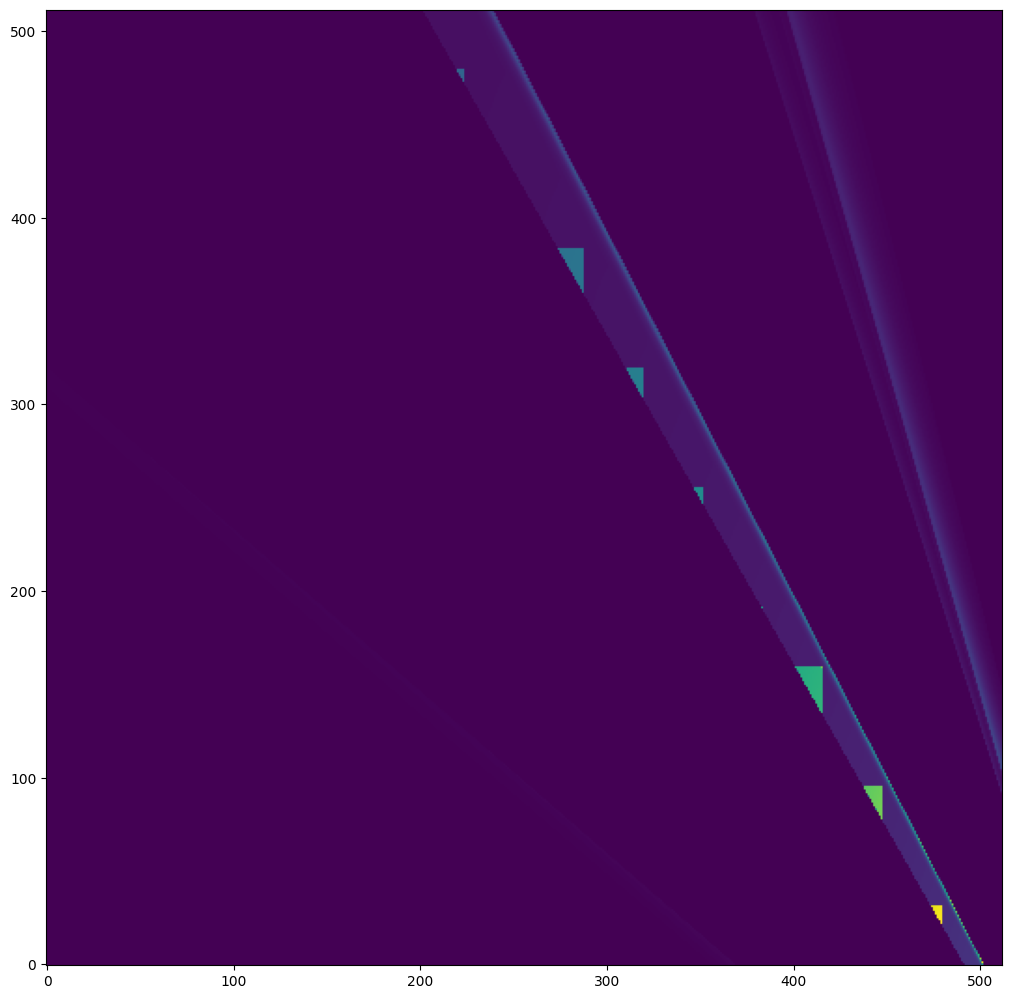

In [12]:
import matplotlib.pyplot as plt

plt.close("all")
fig, ax = plt.subplots(figsize=(10, 10), layout="constrained")
ax.imshow(ppdf.cpu().view(512,512).T,origin='lower')